In [78]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

In [79]:
df = pd.read_csv("avocado.csv", index_col=0)

In [80]:
df

,Date,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region
0,2015-12-27,1.33,64236.62,1036.74,54454.85,48.16,8696.87,8603.62,93.25,0.0,conventional,2015,Albany
1,2015-12-20,1.35,54876.98,674.28,44638.81,58.33,9505.56,9408.07,97.49,0.0,conventional,2015,Albany
2,2015-12-13,0.93,118220.22,794.70,109149.67,130.50,8145.35,8042.21,103.14,0.0,conventional,2015,Albany
3,2015-12-06,1.08,78992.15,1132.00,71976.41,72.58,5811.16,5677.40,133.76,0.0,conventional,2015,Albany
4,2015-11-29,1.28,51039.60,941.48,43838.39,75.78,6183.95,5986.26,197.69,0.0,conventional,2015,Albany
...,...,...,...,...,...,...,...,...,...,...,...,...,...
7,2018-02-04,1.63,17074.83,2046.96,1529.20,0.00,13498.67,13066.82,431.85,0.0,organic,2018,WestTexNewMexico
8,2018-01-28,1.71,13888.04,1191.70,3431.50,0.00,9264.84,8940.04,324.80,0.0,organic,2018,WestTexNewMexico
9,2018-01-21,1.87,13766.76,1191.92,2452.79,727.94,9394.11,9351.80,42.31,0.0,organic,2018,WestTexNewMexico
10,2018-01-14,1.93,16205.22,1527.63,2981.04,727.01,10969.54,10919.54,50.00,0.0,organic,2018,WestTexNewMexico


In [81]:
df.columns = df.columns.str.lower().str.replace(" ", "_")

In [82]:
df = df.rename(columns={"averageprice": "average_price"})

In [83]:
df["date"] = pd.to_datetime(df["date"])

In [84]:
df["type"] = pd.Categorical(df["type"])
df["region"] = pd.Categorical(df["region"])

In [85]:
df

,date,average_price,total_volume,4046,4225,4770,total_bags,small_bags,large_bags,xlarge_bags,type,year,region
0,2015-12-27,1.33,64236.62,1036.74,54454.85,48.16,8696.87,8603.62,93.25,0.0,conventional,2015,Albany
1,2015-12-20,1.35,54876.98,674.28,44638.81,58.33,9505.56,9408.07,97.49,0.0,conventional,2015,Albany
2,2015-12-13,0.93,118220.22,794.70,109149.67,130.50,8145.35,8042.21,103.14,0.0,conventional,2015,Albany
3,2015-12-06,1.08,78992.15,1132.00,71976.41,72.58,5811.16,5677.40,133.76,0.0,conventional,2015,Albany
4,2015-11-29,1.28,51039.60,941.48,43838.39,75.78,6183.95,5986.26,197.69,0.0,conventional,2015,Albany
...,...,...,...,...,...,...,...,...,...,...,...,...,...
7,2018-02-04,1.63,17074.83,2046.96,1529.20,0.00,13498.67,13066.82,431.85,0.0,organic,2018,WestTexNewMexico
8,2018-01-28,1.71,13888.04,1191.70,3431.50,0.00,9264.84,8940.04,324.80,0.0,organic,2018,WestTexNewMexico
9,2018-01-21,1.87,13766.76,1191.92,2452.79,727.94,9394.11,9351.80,42.31,0.0,organic,2018,WestTexNewMexico
10,2018-01-14,1.93,16205.22,1527.63,2981.04,727.01,10969.54,10919.54,50.00,0.0,organic,2018,WestTexNewMexico


In [86]:

numerics = df.drop("average_price", axis=1).select_dtypes("number").columns.to_list()
categorics = df.select_dtypes("category").columns.to_list()
time = ["date"]

<Axes: >

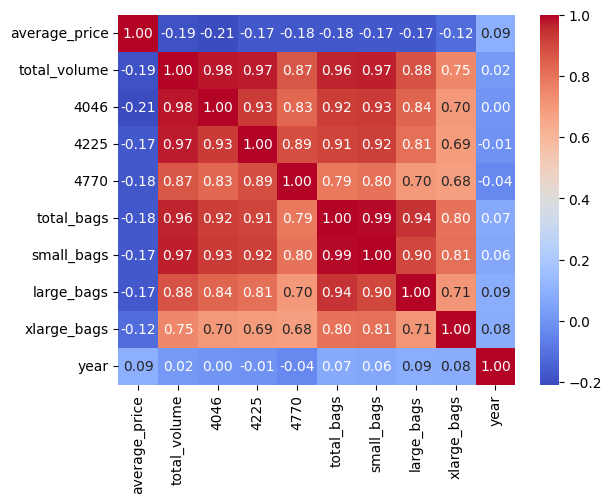

In [87]:
sns.heatmap(df.select_dtypes("number").corr(), annot=True, cmap="coolwarm", fmt=".2f")

In [89]:
# PCA for correlated features
from sklearn.decomposition import PCA
pca = PCA(n_components=3)
pca.fit(df[numerics])
print("Explained variance ratio:", pca.explained_variance_ratio_)
# Plotting PCA components
pca_df = pd.DataFrame(pca.transform(df[numerics]), columns=[f"PC{i+1}" for i in range(3)])
df = pd.concat([df.drop(numerics, axis=1).reset_index(drop=True), pca_df], axis=1)

Explained variance ratio: [0.98396912 0.00855784 0.00662382]


/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: invalid value encountered in matmul
  X_transformed = X @ self.components_.T


/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: divide by zero encountered in matmul
  return _core_matmul(x1, x2)
/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: overflow encountered in matmul
  return _core_matmul(x1, x2)
/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: invalid value encountered in matmul
  return _core_matmul(x1, x2)


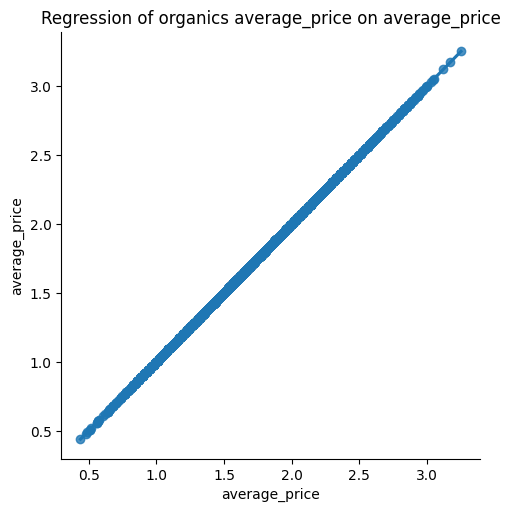

/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: divide by zero encountered in matmul
  return _core_matmul(x1, x2)
/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: overflow encountered in matmul
  return _core_matmul(x1, x2)
/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: invalid value encountered in matmul
  return _core_matmul(x1, x2)


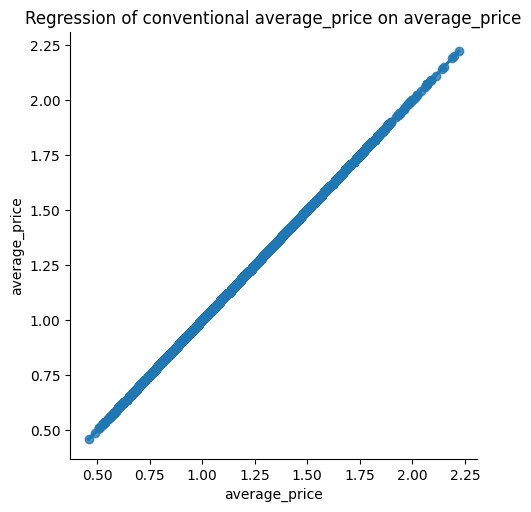

/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: divide by zero encountered in matmul
  return _core_matmul(x1, x2)
/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: overflow encountered in matmul
  return _core_matmul(x1, x2)
/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: invalid value encountered in matmul
  return _core_matmul(x1, x2)


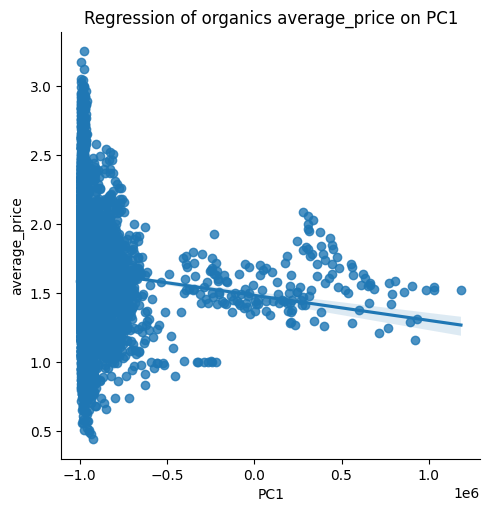

/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: divide by zero encountered in matmul
  return _core_matmul(x1, x2)
/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: overflow encountered in matmul
  return _core_matmul(x1, x2)
/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: invalid value encountered in matmul
  return _core_matmul(x1, x2)


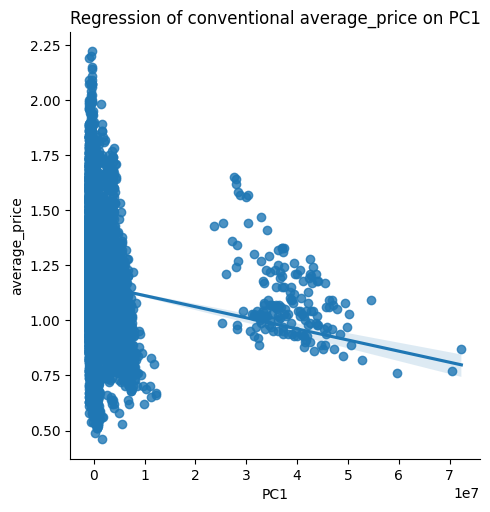

/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: divide by zero encountered in matmul
  return _core_matmul(x1, x2)
/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: overflow encountered in matmul
  return _core_matmul(x1, x2)
/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: invalid value encountered in matmul
  return _core_matmul(x1, x2)


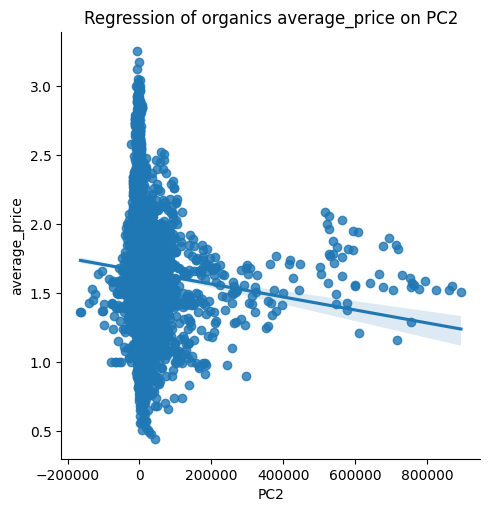

/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: divide by zero encountered in matmul
  return _core_matmul(x1, x2)
/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: overflow encountered in matmul
  return _core_matmul(x1, x2)
/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: invalid value encountered in matmul
  return _core_matmul(x1, x2)


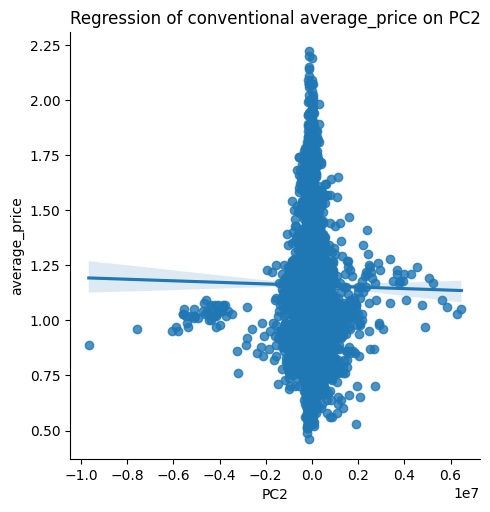

/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: divide by zero encountered in matmul
  return _core_matmul(x1, x2)
/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: overflow encountered in matmul
  return _core_matmul(x1, x2)
/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: invalid value encountered in matmul
  return _core_matmul(x1, x2)


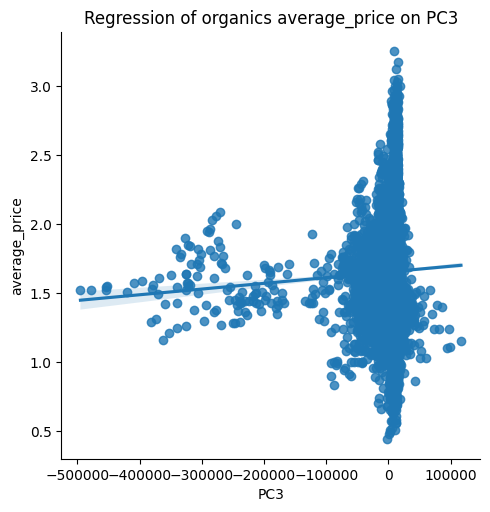

/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: divide by zero encountered in matmul
  return _core_matmul(x1, x2)
/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: overflow encountered in matmul
  return _core_matmul(x1, x2)
/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: invalid value encountered in matmul
  return _core_matmul(x1, x2)


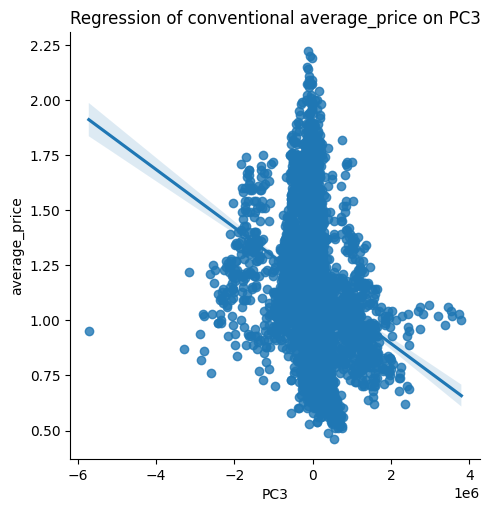

In [90]:
numerics = df.select_dtypes("number").columns.to_list()
# Plot numerics against target
for feature in numerics:
    sns.lmplot(df[df["type"] == "organic"], x=feature, y="average_price", lowess=False)
    plt.title(f"Regression of organics average_price on {feature}")
    plt.show()
    sns.lmplot(df[df["type"] == "conventional"], x=feature, y="average_price", lowess=False)
    plt.title(f"Regression of conventional average_price on {feature}")
    plt.show()

/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: divide by zero encountered in matmul
  return _core_matmul(x1, x2)
/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: overflow encountered in matmul
  return _core_matmul(x1, x2)
/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: invalid value encountered in matmul
  return _core_matmul(x1, x2)


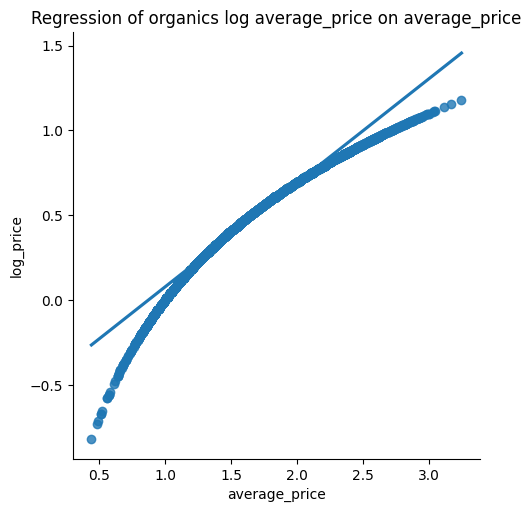

/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: divide by zero encountered in matmul
  return _core_matmul(x1, x2)
/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: overflow encountered in matmul
  return _core_matmul(x1, x2)
/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: invalid value encountered in matmul
  return _core_matmul(x1, x2)


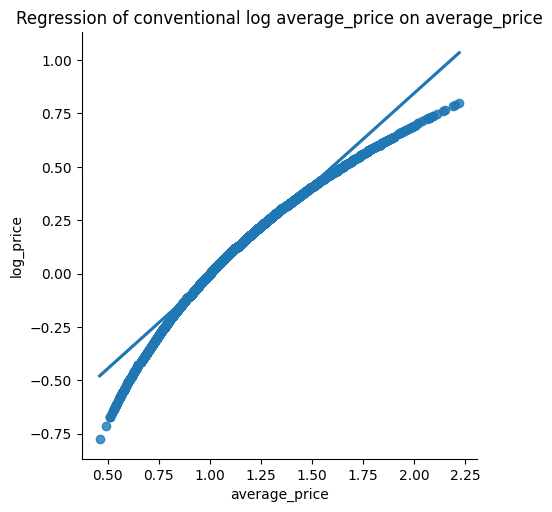

/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: divide by zero encountered in matmul
  return _core_matmul(x1, x2)
/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: overflow encountered in matmul
  return _core_matmul(x1, x2)
/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: invalid value encountered in matmul
  return _core_matmul(x1, x2)


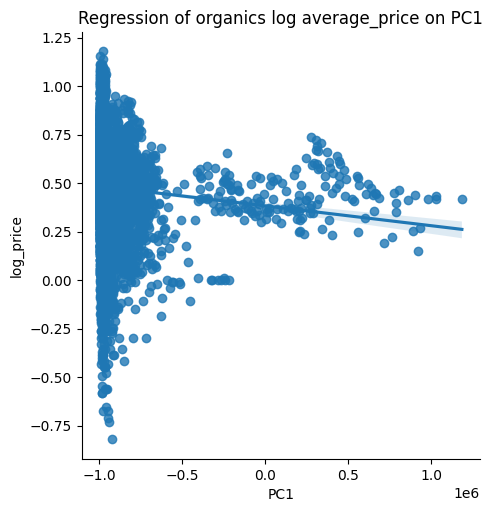

/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: divide by zero encountered in matmul
  return _core_matmul(x1, x2)
/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: overflow encountered in matmul
  return _core_matmul(x1, x2)
/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: invalid value encountered in matmul
  return _core_matmul(x1, x2)


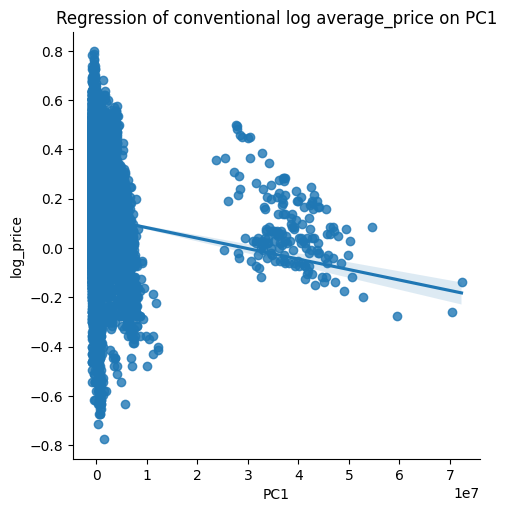

/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: divide by zero encountered in matmul
  return _core_matmul(x1, x2)
/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: overflow encountered in matmul
  return _core_matmul(x1, x2)
/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: invalid value encountered in matmul
  return _core_matmul(x1, x2)


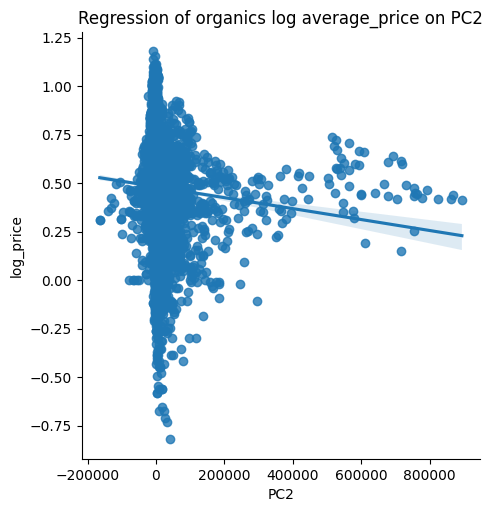

/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: divide by zero encountered in matmul
  return _core_matmul(x1, x2)
/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: overflow encountered in matmul
  return _core_matmul(x1, x2)
/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: invalid value encountered in matmul
  return _core_matmul(x1, x2)


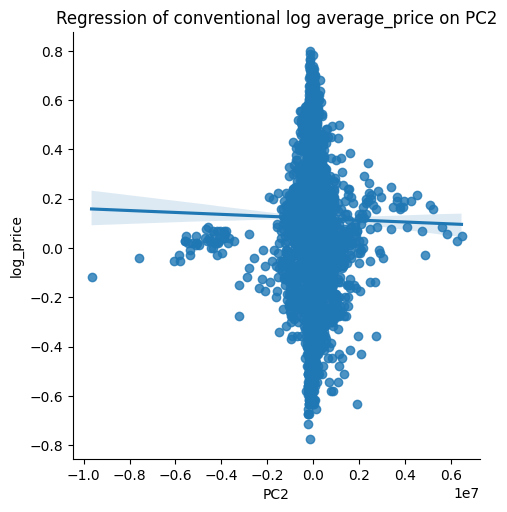

/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: divide by zero encountered in matmul
  return _core_matmul(x1, x2)
/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: overflow encountered in matmul
  return _core_matmul(x1, x2)
/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: invalid value encountered in matmul
  return _core_matmul(x1, x2)


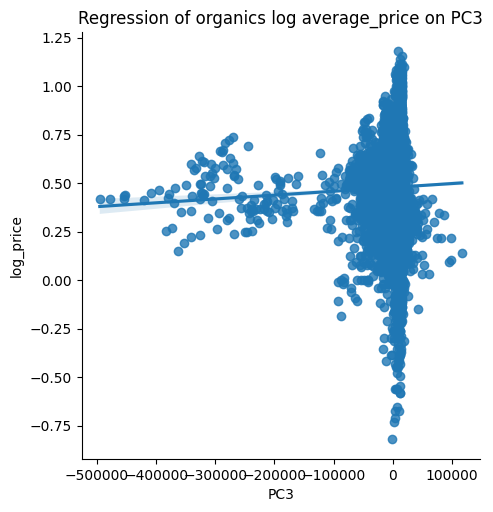

/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: divide by zero encountered in matmul
  return _core_matmul(x1, x2)
/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: overflow encountered in matmul
  return _core_matmul(x1, x2)
/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: invalid value encountered in matmul
  return _core_matmul(x1, x2)


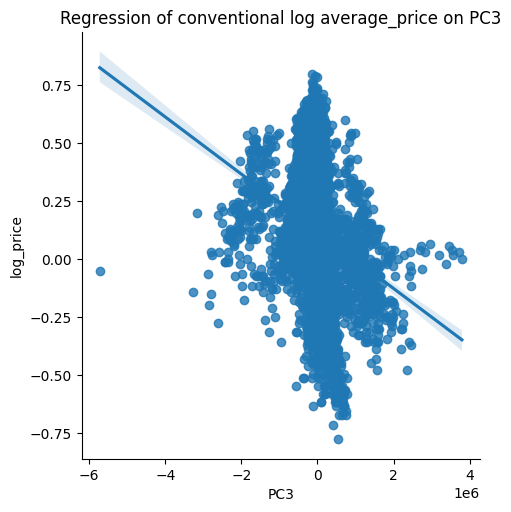

In [91]:
df["log_price"] = np.log(df["average_price"])
# Plot numerics against target
for feature in numerics:
    sns.lmplot(df[df["type"] == "organic"], x=feature, y="log_price", lowess=False)
    plt.title(f"Regression of organics log average_price on {feature}")
    plt.show()
    sns.lmplot(df[df["type"] == "conventional"], x=feature, y="log_price", lowess=False)
    plt.title(f"Regression of conventional log average_price on {feature}")
    plt.show()

In [ ]:
df.groupby([df["date"].dt.year, df["date"].dt.month])["average_price"].agg("mean")

date  date
2015  1       1.365046
      2       1.326944
      3       1.361981
      4       1.383449
      5       1.344685
      6       1.399074
      7       1.409444
      8       1.444481
      9       1.449144
      10      1.391968
      11      1.330611
      12      1.305244
2016  1       1.240185
      2       1.237106
      3       1.224213
      4       1.205023
      5       1.199722
      6       1.283056
      7       1.401333
      8       1.411111
      9       1.427870
      10      1.557093
      11      1.550023
      12      1.315995
2017  1       1.277500
      2       1.214792
      3       1.398935
      4       1.502611
      5       1.532593
      6       1.545395
      7       1.564926
      8       1.698958
      9       1.840949
      10      1.752444
      11      1.517292
      12      1.363852
2018  1       1.387431
      2       1.318704
      3       1.336458
Name: average_price, dtype: float64

In [ ]:
df.groupby([df["date"].dt.year, df["date"].dt.month])["average_price"].agg("mean")

date  date
2015  1       1.365046
      2       1.326944
      3       1.361981
      4       1.383449
      5       1.344685
      6       1.399074
      7       1.409444
      8       1.444481
      9       1.449144
      10      1.391968
      11      1.330611
      12      1.305244
2016  1       1.240185
      2       1.237106
      3       1.224213
      4       1.205023
      5       1.199722
      6       1.283056
      7       1.401333
      8       1.411111
      9       1.427870
      10      1.557093
      11      1.550023
      12      1.315995
2017  1       1.277500
      2       1.214792
      3       1.398935
      4       1.502611
      5       1.532593
      6       1.545395
      7       1.564926
      8       1.698958
      9       1.840949
      10      1.752444
      11      1.517292
      12      1.363852
2018  1       1.387431
      2       1.318704
      3       1.336458
Name: average_price, dtype: float64

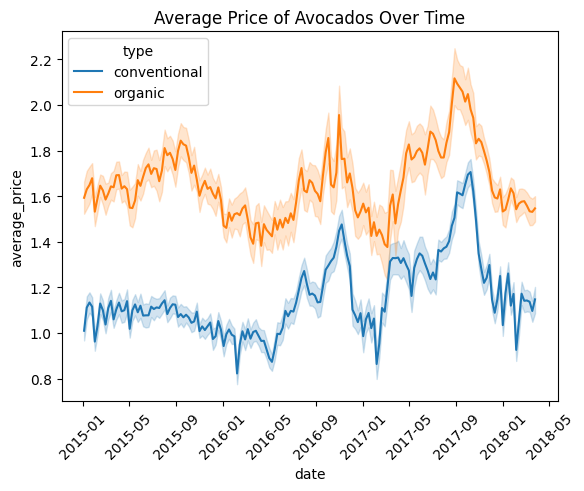

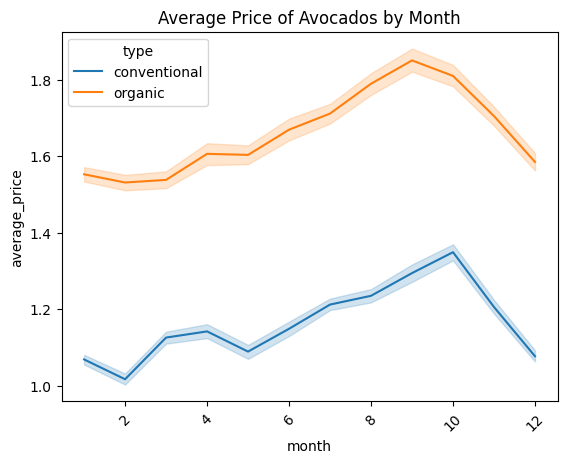

In [92]:
# Plot average_price over the years
sns.lineplot(data=df, x="date", y="average_price", hue="type")
plt.title("Average Price of Avocados Over Time")
plt.xticks(rotation=45)
plt.show()

# Assess cyclicity
df["month"] = df["date"].dt.month
df["year"] = df["date"].dt.year
sns.lineplot(data=df, x="month", y="average_price", hue="type")
plt.title("Average Price of Avocados by Month")
plt.xticks(rotation=45)
plt.show()
# Assess cyclicity by year

In [ ]:
df["month"] = df["date"].dt.month
df["year"] = df["date"].dt.year

# Prepare data for linear model

In [109]:
X = df[numerics + ["type", "month", "year"]].drop("average_price", axis=1)
X = sm.add_constant(X)
dummies = pd.get_dummies(X["type"], prefix="type", drop_first=True, dtype=int)
X = pd.concat([X, dummies], axis=1)
X = X.drop(columns=["type"])

X["yearB2015"] = X["year"] - 2015
X = X.drop("year", axis=1)
X["Month2"] = X["month"] **2
y = df["average_price"]

In [110]:
# Train-test-split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [111]:
# Standardize numerics
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
standardize = ["PC1", "PC2", "PC3"]

X_train[standardize] = scaler.fit_transform(X_train[standardize])
X_test[standardize] = scaler.transform(X_test[standardize])

In [112]:
X_train

,const,PC1,PC2,PC3,month,type_organic,yearB2015,Month2
16391,1.0,-0.247716,0.004778,0.033930,11,1,2,121
4990,1.0,-0.079261,0.305284,-0.082499,1,0,1,1
13653,1.0,-0.247472,-0.005929,0.038227,11,1,1,121
2074,1.0,-0.206380,-0.028694,0.129093,2,0,0,4
12377,1.0,-0.237685,-0.065415,-0.026511,6,1,1,36
...,...,...,...,...,...,...,...,...
11284,1.0,-0.245655,-0.023282,0.027909,6,1,0,36
11964,1.0,-0.249031,-0.004427,0.038330,5,1,1,25
5390,1.0,-0.224617,-0.021353,-0.078796,5,0,1,25
860,1.0,-0.166778,0.000868,-0.192651,6,0,0,36


# Fit linear OLS

In [122]:
OLS = sm.OLS(y_train, X_train).fit(cov_type="HC3")
print(OLS.summary())

OLS_preds = OLS.predict(X_test)
from sklearn.metrics import mean_squared_error as MSE, mean_absolute_error as MAE, r2_score

print(f"MSE: {MSE(y_test, OLS_preds)}, MAE: {MAE(y_test, OLS_preds)}, R2: {r2_score(y_test, OLS_preds)}")

                            OLS Regression Results                            
Dep. Variable:          average_price   R-squared:                       0.451
Model:                            OLS   Adj. R-squared:                  0.451
Method:                 Least Squares   F-statistic:                     1672.
Date:                Tue, 29 Jul 2025   Prob (F-statistic):               0.00
Time:                        15:45:13   Log-Likelihood:                -3074.0
No. Observations:               14599   AIC:                             6164.
Df Residuals:                   14591   BIC:                             6225.
Df Model:                           7                                         
Covariance Type:                  HC3                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const            0.8308      0.009     89.178   

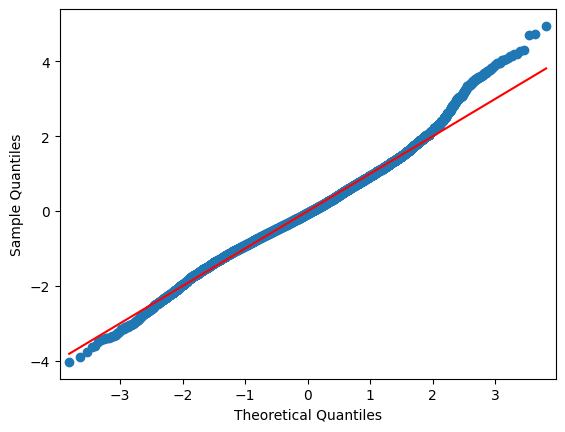

In [118]:
qq = sm.qqplot(OLS.resid_pearson, line="s")

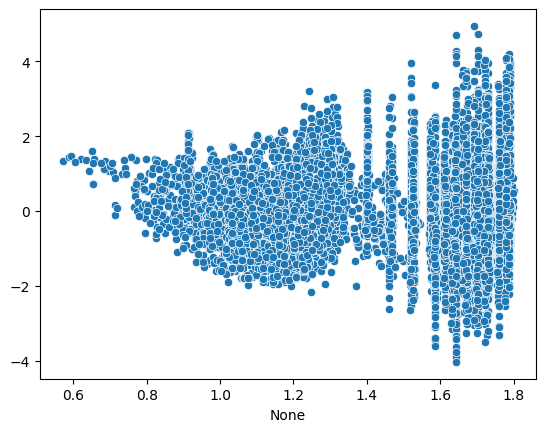

In [119]:
fitted = sns.scatterplot(x=OLS.fittedvalues, y = OLS.resid_pearson)

# Fit Gamma GLM

In [124]:
Gamma = sm.GLM(y_train, X_train, sm.families.Gamma(sm.families.links.Log())).fit()
print(Gamma.summary())

Gamma_preds = Gamma.predict(X_test)
from sklearn.metrics import mean_squared_error as MSE, mean_absolute_error as MAE, r2_score

print(f"MSE: {MSE(y_test, Gamma_preds)}, MAE: {MAE(y_test, Gamma_preds)}, R2: {r2_score(y_test, Gamma_preds)}")

                 Generalized Linear Model Regression Results                  
Dep. Variable:          average_price   No. Observations:                14599
Model:                            GLM   Df Residuals:                    14591
Model Family:                   Gamma   Df Model:                            7
Link Function:                    Log   Scale:                        0.042415
Method:                          IRLS   Log-Likelihood:                -2314.7
Date:                Tue, 29 Jul 2025   Deviance:                       640.90
Time:                        15:46:35   Pearson chi2:                     619.
No. Iterations:                    12   Pseudo R-squ. (CS):             0.5974
Covariance Type:            nonrobust                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const           -0.0950      0.007    -13.994   

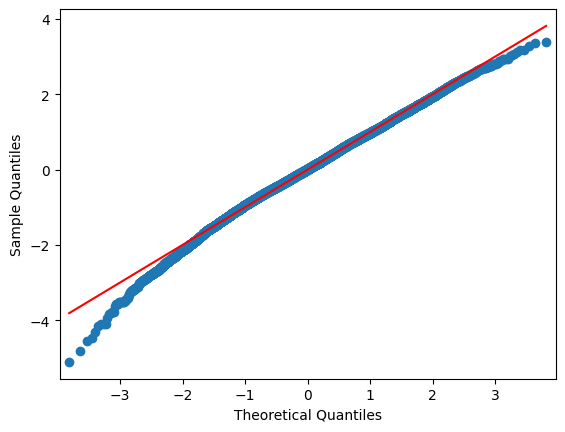

In [126]:
from scipy import stats
qq = sm.qqplot(stats.zscore(Gamma.resid_deviance), line="s")

In [131]:
# Fit XGBoost for comparison
from xgboost import XGBRegressor
xgb = XGBRegressor(n_estimators=1000, learning_rate=0.01).fit(X=X_train, y=y_train)

In [132]:
xgb_preds = xgb.predict(X_test)

print(f"MSE: {MSE(y_test, xgb_preds)}, MAE: {MAE(y_test, xgb_preds)}, R2: {r2_score(y_test, xgb_preds)}")

MSE: 0.04254792532832943, MAE: 0.14809547092359363, R2: 0.7351828712173691


In [135]:
results = pd.DataFrame({"Names": xgb.feature_names_in_, "Importance": xgb.feature_importances_})

In [139]:
results.sort_values(by="Importance", ascending=False)

,Names,Importance
5,type_organic,0.931015
6,yearB2015,0.021924
4,month,0.017513
2,PC2,0.011971
3,PC3,0.010514
1,PC1,0.007063
0,const,0.000000
7,Month2,0.000000
